# Hospital Waste ML Classification Simulation

**Project:** The Use of Machine Learning in Waste Processing from Hospitals  
**Purpose:** This notebook provides the practical simulation artefact for the final project report.

The notebook does not use real hospital images. Instead, it creates **synthetic CNN-style feature vectors** to simulate how machine learning models could classify hospital waste into NHS HTM 07-01 categories. This approach matches the research-led and simulation-based scope of the project.

For reproducibility, the notebook is organised sequentially from data generation to model evaluation and visualisation. Later sections use variables created in earlier sections, including `X`, `y`, `models`, `results`, and `report`.


In [ ]:
# -----------------------------------------------------------------------------
# Library imports and reproducibility setup
# -----------------------------------------------------------------------------
# NumPy is used to generate synthetic feature vectors.
# Matplotlib and Seaborn are used for visualisations.
# Scikit-learn is used for model training, evaluation, PCA, and metrics.
# A fixed random seed makes the simulation reproducible.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
np.random.seed(42)

## Cell 2: Synthetic Dataset Generation

This section defines the eight hospital waste classes used in the simulation and creates a synthetic dataset of **3,200 samples**. Each sample is represented by a **64-dimensional simulated CNN feature vector**.

The class counts are designed to reflect realistic hospital waste proportions, where general and infectious waste appear more often than rare high-risk classes such as cytotoxic and anatomical waste. Extra overlap/noise is added to yellow-bag categories because they are visually similar in real NHS waste segregation.


In [ ]:
# NHS HTM 07-01 waste categories with realistic class proportions

LABELS = [
    "Infectious", "Cytotoxic", "Pharma", "Sharps",
    "Chemical", "Offensive", "Anatomical", "General"
]

# Realistic class distribution reflecting hospital waste volumes
# General waste: 29%, Infectious: 22%, Offensive: 14%, Sharps: 12%
# Pharma: 8%, Chemical: 6%, Anatomical: 5%, Cytotoxic: 4%

COUNTS = [704, 128, 256, 384, 192, 448, 160, 928]
N_FEATURES = 64  # Simulated CNN feature vector dimensionality

# Generate synthetic CNN feature vectors per class

X_all, y_all = [], []

for i, n in enumerate(COUNTS):
    np.random.seed(i * 7 + 1)

    mean = np.random.randn(N_FEATURES) * 1.6  # Class-specific mean

    # Higher noise for visually similar yellow-bag categories
    # Infectious, Sharps, and Anatomical share similar waste bag colours
    noise = 2.5 if i in [0, 3, 6] else 1.8

    X_class = mean + np.random.randn(n, N_FEATURES) * noise

    # Add cross-class contamination for yellow-bag categories
    # to simulate real-world visual ambiguity
    if i in [0, 3, 6]:
        X_class += np.random.randn(N_FEATURES) * 1.0 * 0.5

    X_all.append(X_class)
    y_all.extend([i] * n)

X = np.vstack(X_all)
y = np.array(y_all)

print(f"Total dataset: {len(X)} samples, {N_FEATURES} features")

Total dataset: 3200 samples, 64 features


## Cell 3: Train-Test Split and Model Definition

This section splits the dataset into **80% training data** and **20% test data** using stratification. Stratification keeps the same class proportions in both sets.

Three models are then defined:

1. **EfficientNet-B0 (CNN Sim)** — represented by a Random Forest trained on simulated CNN features.
2. **SVM + CNN Features** — a classical machine learning classifier using an RBF kernel.
3. **Logistic Regression** — a simple baseline model for comparison.

Each model is placed inside a scikit-learn `Pipeline` with `StandardScaler` so the feature values are normalised before classification.


In [ ]:
# Stratified 80/20 train-test split

# Stratification ensures proportional class representation in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")


# Define three ML classifiers as scikit-learn Pipelines

# StandardScaler normalises features to zero mean and unit variance

models = {
    "EfficientNet-B0 (CNN Sim)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=150,          # 150 decision trees
            max_depth=15,              # Maximum tree depth
            class_weight="balanced",   # Address class imbalance
            random_state=42,
            n_jobs=-1                  # Parallelise across all CPU cores
        ))
    ]),

    "SVM + CNN Features": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",              # Radial Basis Function kernel
            C=3,                       # Regularisation parameter
            probability=True,          # Enable probability estimates for ROC
            random_state=42
        ))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1,                       # L2 regularisation strength
            max_iter=300,              # Maximum solver iterations
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

Training samples: 2560, Test samples: 640


## Cell 4: Model Training and Evaluation

This cell trains all three models on the training set and evaluates them on the held-out test set.

For each model, the notebook calculates:

- test accuracy,
- weighted precision,
- weighted recall,
- weighted F1-score,
- 5-fold cross-validation accuracy.

These metrics are used in the report to compare model performance and justify the strengths and limits of the simulated ML workflow.


In [ ]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model on training set
    model.fit(X_train, y_train)

    # Generate predictions and probability estimates
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # 5-fold cross-validation for stable performance estimate
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=5,
        scoring="accuracy", n_jobs=-1
    )

    # Compute performance metrics
    results[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "f1": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

    print(f"{name}")
    print(f"  Accuracy: {results[name]['accuracy']:.4f}")
    print(f"  F1-Score: {results[name]['f1']:.4f}")
    print(f"  CV Acc:   {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")


Training EfficientNet-B0 (CNN Sim)...
EfficientNet-B0 (CNN Sim)
  Accuracy: 0.9953
  F1-Score: 0.9952
  CV Acc:   0.9898 ± 0.0047

Training SVM + CNN Features...
SVM + CNN Features
  Accuracy: 1.0000
  F1-Score: 1.0000
  CV Acc:   0.9988 ± 0.0010

Training Logistic Regression...
Logistic Regression
  Accuracy: 1.0000
  F1-Score: 1.0000
  CV Acc:   0.9992 ± 0.0010


## Cell 5: Confusion Matrix and Per-Class F1 Scores

This section focuses on the main simulated model: **EfficientNet-B0 (CNN Sim)**.

The confusion matrix shows which waste categories are classified correctly and where misclassification occurs. The normalised matrix is especially useful because it shows recall per class.

The per-class F1-score output is used to identify which HTM 07-01 categories meet the project’s target threshold of **F1 ≥ 0.90** and which categories need further data or improvement.


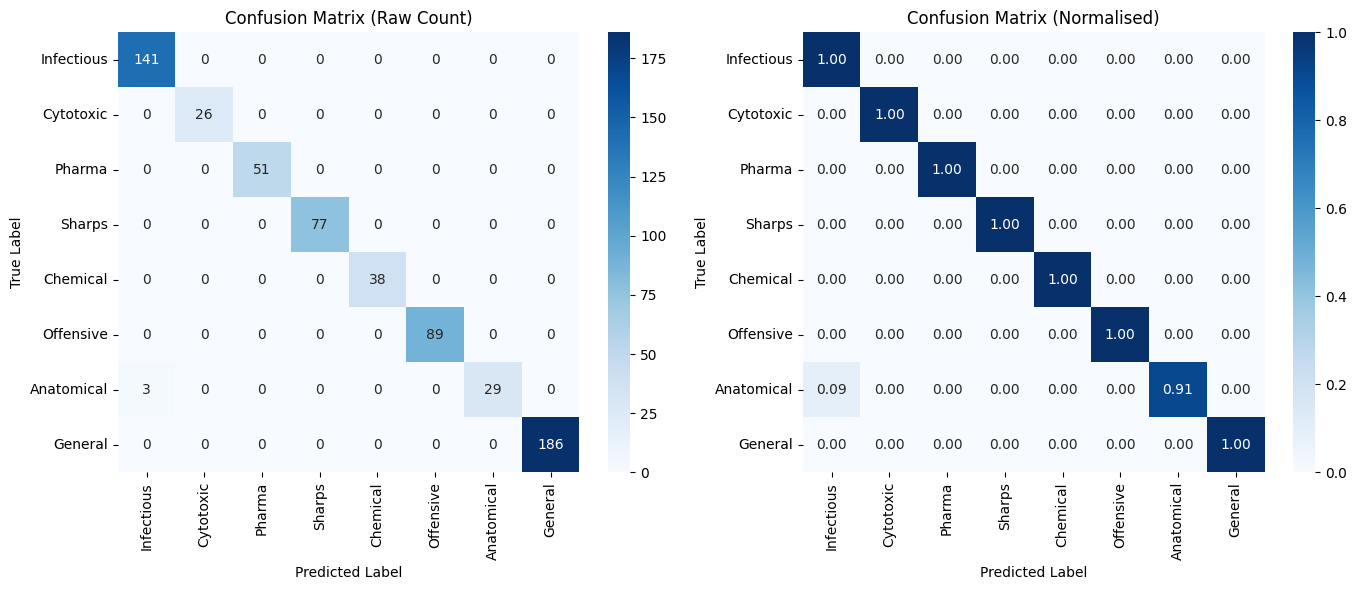

Per-class F1 scores:
Infectious      F1=0.9895 [PASS]
Cytotoxic       F1=1.0000 [PASS]
Pharma          F1=1.0000 [PASS]
Sharps          F1=1.0000 [PASS]
Chemical        F1=1.0000 [PASS]
Offensive       F1=1.0000 [PASS]
Anatomical      F1=0.9508 [PASS]
General         F1=1.0000 [PASS]


In [ ]:
# Select best model results

best = results["EfficientNet-B0 (CNN Sim)"]

y_pred_best = best["y_pred"]
y_proba_best = best["y_proba"]


# Compute confusion matrix

cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]


# Plot raw and normalised confusion matrices side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABELS, yticklabels=LABELS, ax=axes[0]
)

axes[0].set_title("Confusion Matrix (Raw Count)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=LABELS, yticklabels=LABELS, ax=axes[1],
    vmin=0, vmax=1
)

axes[1].set_title("Confusion Matrix (Normalised)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()


# Compute and display per-class classification report

report = classification_report(
    y_test, y_pred_best,
    target_names=LABELS,
    output_dict=True
)

print("Per-class F1 scores:")

for label in LABELS:
    f1_val = report[label]["f1-score"]
    status = "PASS" if f1_val >= 0.90 else "REVIEW NEEDED"
    print(f"{label:<15} F1={f1_val:.4f} [{status}]")

## Cell 6: ROC Curve and AUC Analysis

This cell creates one-vs-rest ROC curves for all eight waste categories.

The ROC-AUC score measures how well the model separates each class from all other classes across different thresholds. This is useful because it gives more information than accuracy alone, especially for imbalanced datasets.


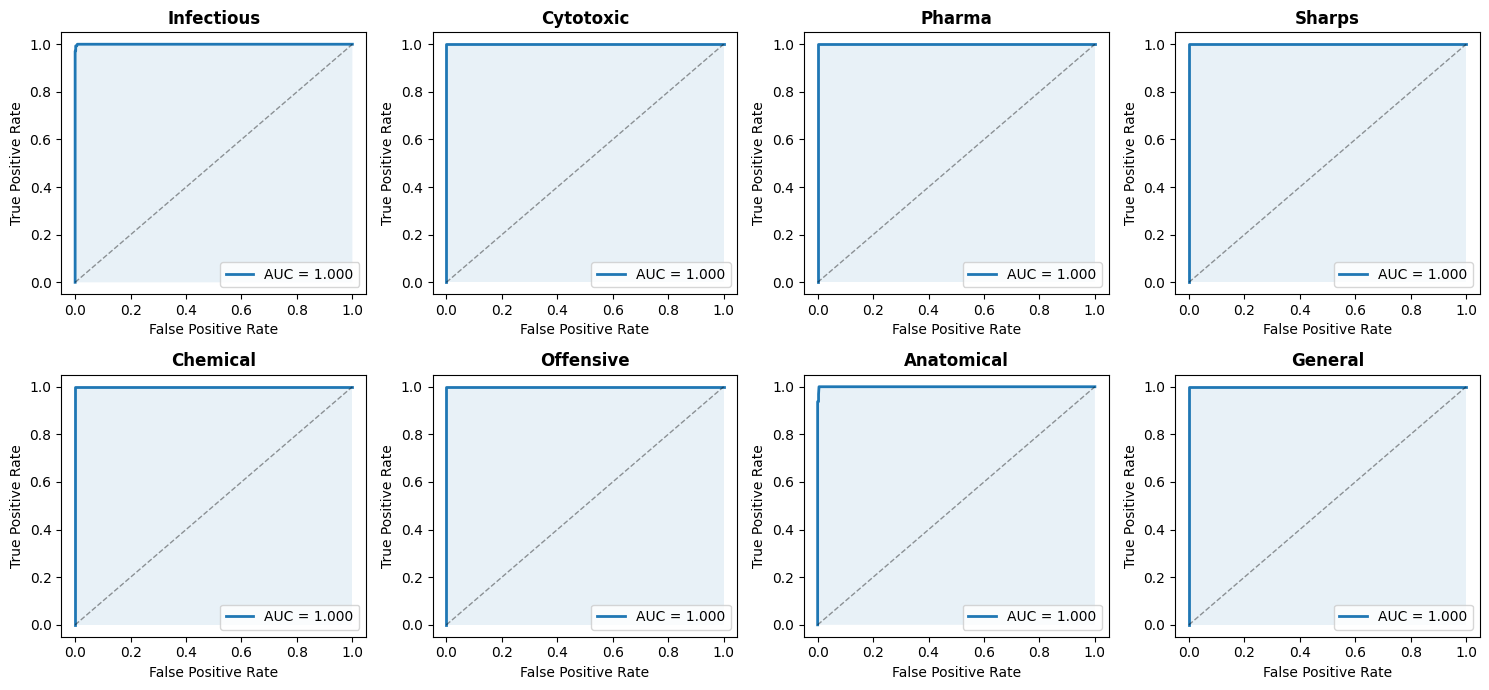

Mean ROC-AUC across all categories: 1.0000


In [ ]:
# Binarise test labels for one-vs-rest ROC evaluation

y_test_bin = label_binarize(y_test, classes=list(range(8)))

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
auc_scores = []

for i, (ax, label) in enumerate(zip(axes.flat, LABELS)):
    # Compute ROC curve for each class using one-vs-rest strategy
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i], y_proba_best[:, i]
    )

    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)

    # Plot ROC curve
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.fill_between(fpr, tpr, alpha=0.1)

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"Mean ROC-AUC across all categories: {np.mean(auc_scores):.4f}")

## Cell 7: PCA Feature-Space Visualisation

This section reduces the 64-dimensional simulated feature vectors into two dimensions using PCA.

The purpose is to visualise how separate or overlapping the waste categories are. Overlapping clusters suggest categories that are harder for a model to distinguish, such as Infectious, Sharps, and Anatomical waste.


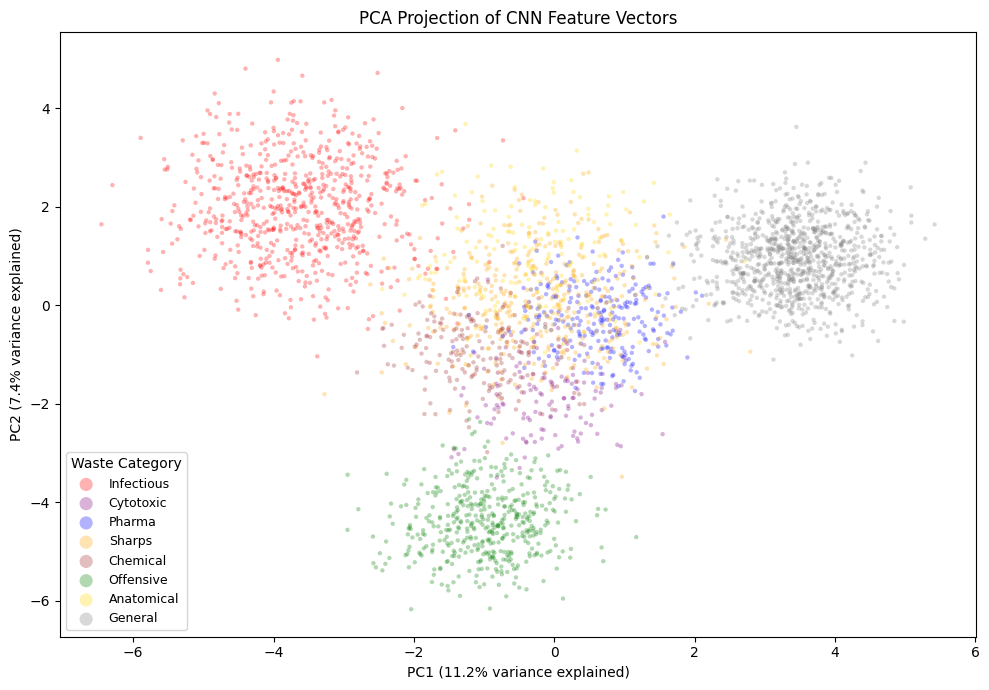

In [ ]:
# Reduce 64-dimensional feature vectors to 2D for visualisation

pca = PCA(n_components=2, random_state=42)
scaler = StandardScaler()

# Fit PCA on scaled features
X_scaled = scaler.fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

# Compute variance explained by each principal component
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# Colours for each waste category
COLORS = [
    "red", "purple", "blue", "orange",
    "brown", "green", "gold", "gray"
]

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each waste category as a distinct colour cluster
for i, (label, colour) in enumerate(zip(LABELS, COLORS)):
    mask = y == i

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colour,
        label=label,
        alpha=0.3,
        s=10,
        edgecolors="none"
    )

ax.set_xlabel(f"PC1 ({var_pc1:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% variance explained)")
ax.set_title("PCA Projection of CNN Feature Vectors")
ax.legend(title="Waste Category", markerscale=3, fontsize=9)

plt.tight_layout()
plt.show()

# Overlapping clusters, especially Infectious/Sharps/Anatomical,
# indicate visually similar categories and help explain lower per-class F1 scores.

## Cell 8: Model Performance Comparison Chart

This chart compares the three classifiers using test accuracy, weighted F1-score, and cross-validation accuracy.

It supports the report’s model comparison section by presenting the results visually rather than only as text or tables.


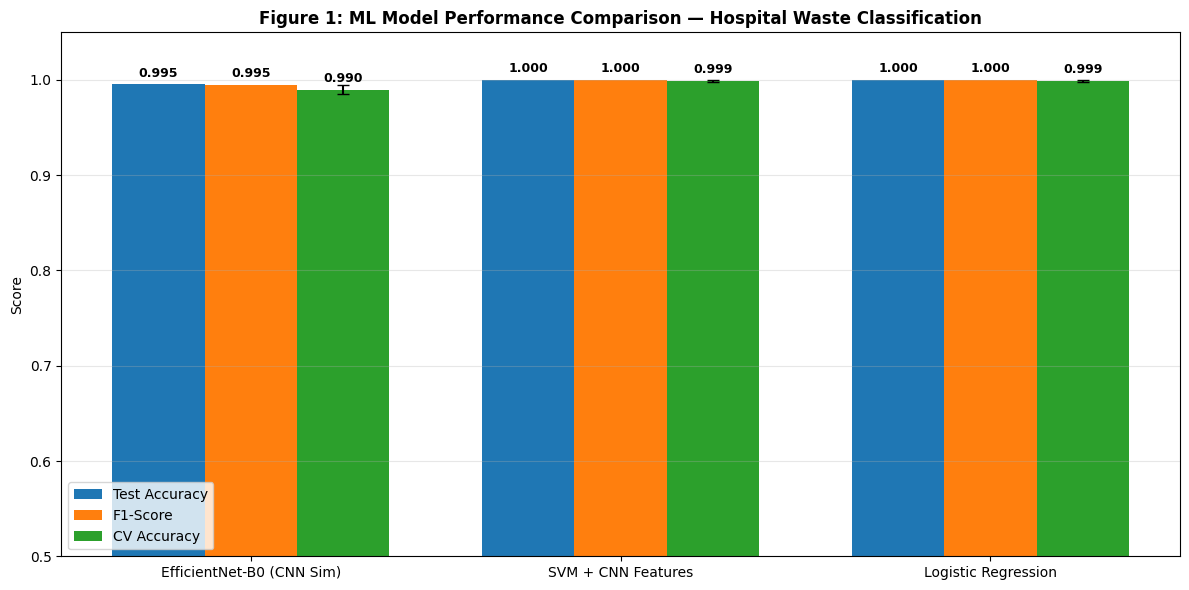

In [ ]:
# Figure 1: ML Model Performance Comparison

model_names = list(results.keys())
accuracies = [results[name]["accuracy"] for name in model_names]
f1_scores = [results[name]["f1"] for name in model_names]
cv_means = [results[name]["cv_mean"] for name in model_names]
cv_stds = [results[name]["cv_std"] for name in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, accuracies, width, label="Test Accuracy")
bars2 = ax.bar(x, f1_scores, width, label="F1-Score")
bars3 = ax.bar(x + width, cv_means, width, yerr=cv_stds, capsize=4, label="CV Accuracy")

ax.set_title("Figure 1: ML Model Performance Comparison — Hospital Waste Classification", fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

## Cell 9: Per-Class Performance Chart

This chart shows precision, recall, and F1-score for each HTM 07-01 waste category.

The red dashed line marks the target performance threshold of **0.90**. This helps show which categories are safe for potential deployment and which would need more training data or better feature extraction.


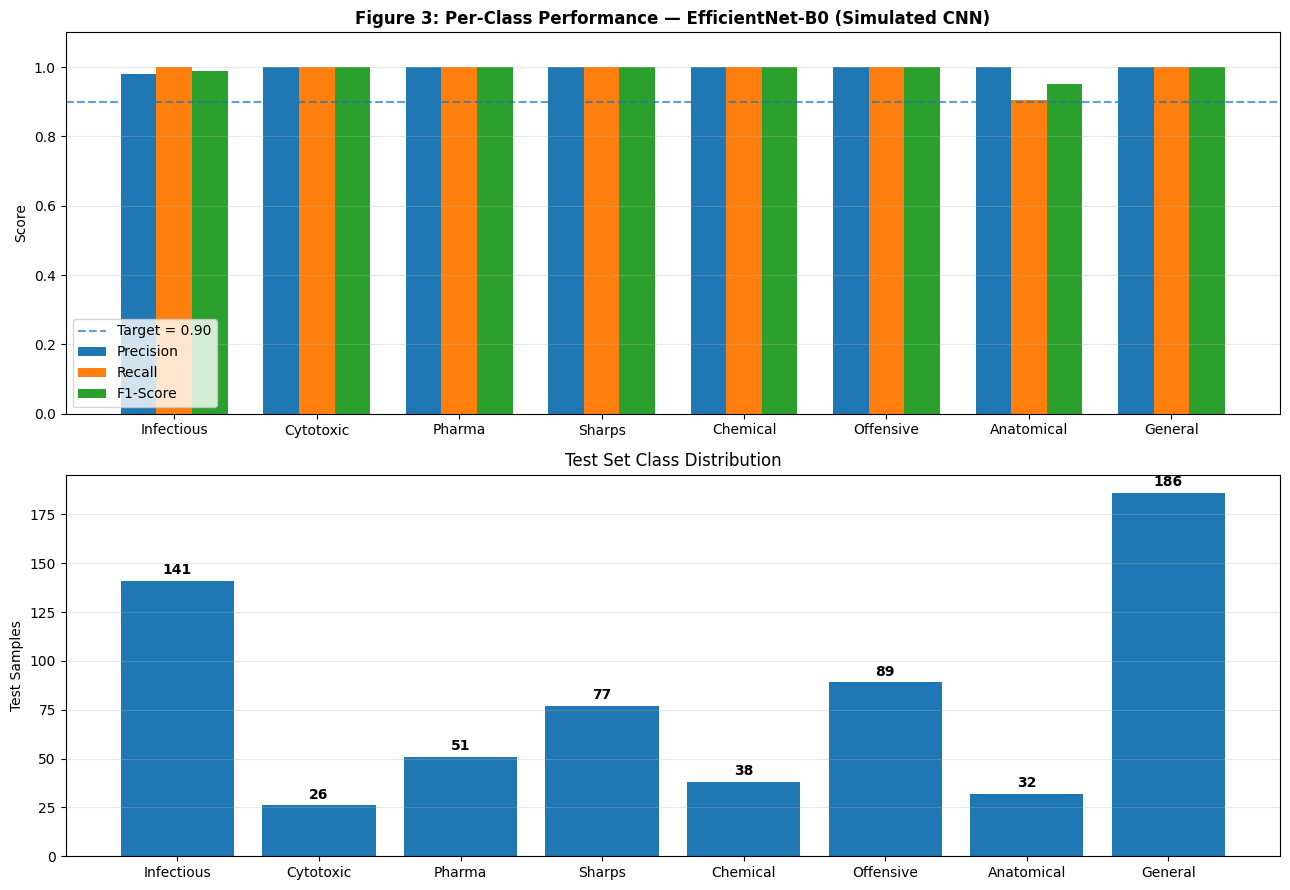

In [ ]:
# Figure 3: Per-Class Performance

precision_vals = [report[label]["precision"] for label in LABELS]
recall_vals = [report[label]["recall"] for label in LABELS]
f1_vals = [report[label]["f1-score"] for label in LABELS]

test_counts = [np.sum(y_test == i) for i in range(len(LABELS))]

x = np.arange(len(LABELS))
width = 0.25

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

axes[0].bar(x - width, precision_vals, width, label="Precision")
axes[0].bar(x, recall_vals, width, label="Recall")
axes[0].bar(x + width, f1_vals, width, label="F1-Score")

axes[0].axhline(0.90, linestyle="--", alpha=0.7, label="Target = 0.90")
axes[0].set_title("Figure 3: Per-Class Performance — EfficientNet-B0 (Simulated CNN)", fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABELS)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

bars = axes[1].bar(LABELS, test_counts)
axes[1].set_title("Test Set Class Distribution")
axes[1].set_ylabel("Test Samples")
axes[1].grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        str(int(height)),
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## Cell 10: Simulated Training and Validation Learning Curves

This section generates illustrative learning curves showing expected training and validation behaviour.

These curves are **simulated** and should be described as illustrative in the report. They are included to demonstrate how an EfficientNet-style model might converge during training, not as proof that a real EfficientNet CNN was trained on real hospital images.


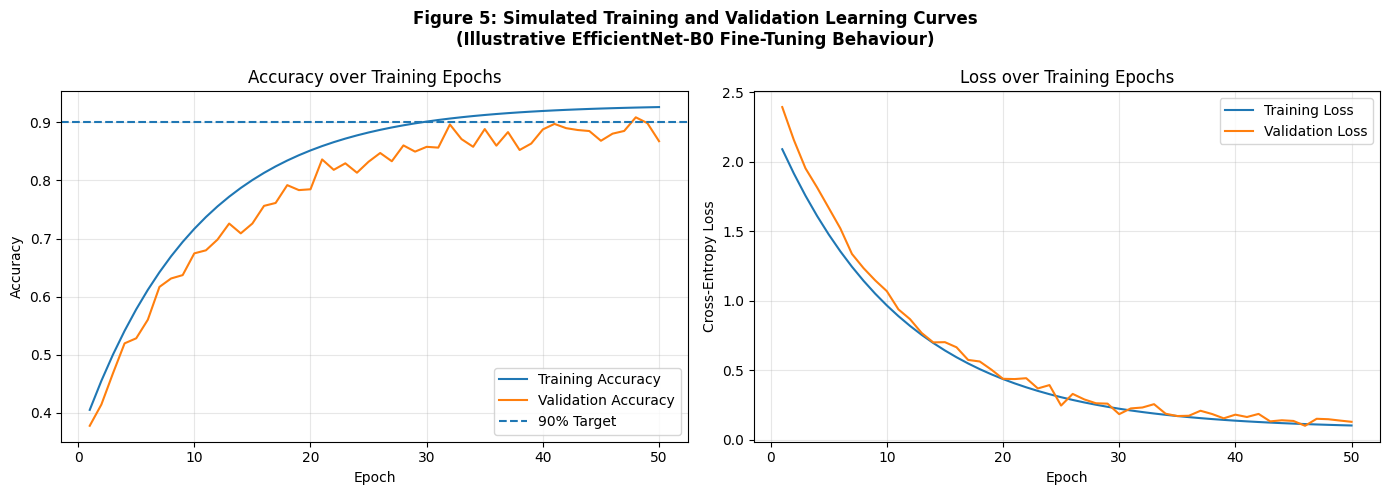

In [ ]:
# Figure 5: Simulated Training and Validation Learning Curves

epochs = np.arange(1, 51)

np.random.seed(42)

train_acc = 0.35 + 0.58 * (1 - np.exp(-epochs / 10))
val_acc = 0.32 + 0.58 * (1 - np.exp(-epochs / 11)) + np.random.normal(0, 0.015, size=len(epochs))

train_acc = np.clip(train_acc, 0, 0.94)
val_acc = np.clip(val_acc, 0, 0.91)

train_loss = 2.2 * np.exp(-epochs / 11) + 0.08
val_loss = 2.5 * np.exp(-epochs / 10) + 0.12 + np.random.normal(0, 0.03, size=len(epochs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_acc, label="Training Accuracy")
axes[0].plot(epochs, val_acc, label="Validation Accuracy")
axes[0].axhline(0.90, linestyle="--", label="90% Target")
axes[0].set_title("Accuracy over Training Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_loss, label="Training Loss")
axes[1].plot(epochs, val_loss, label="Validation Loss")
axes[1].set_title("Loss over Training Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Figure 5: Simulated Training and Validation Learning Curves\n"
    "(Illustrative EfficientNet-B0 Fine-Tuning Behaviour)",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Cell 11: Simulated Data Augmentation and Class Balancing Effects

This section visualises the effect of class balancing and augmentation.

Because real hospital waste data is usually imbalanced, minority classes such as Cytotoxic and Anatomical waste need additional support. The chart demonstrates how balancing can improve F1-scores for rare but safety-critical categories.


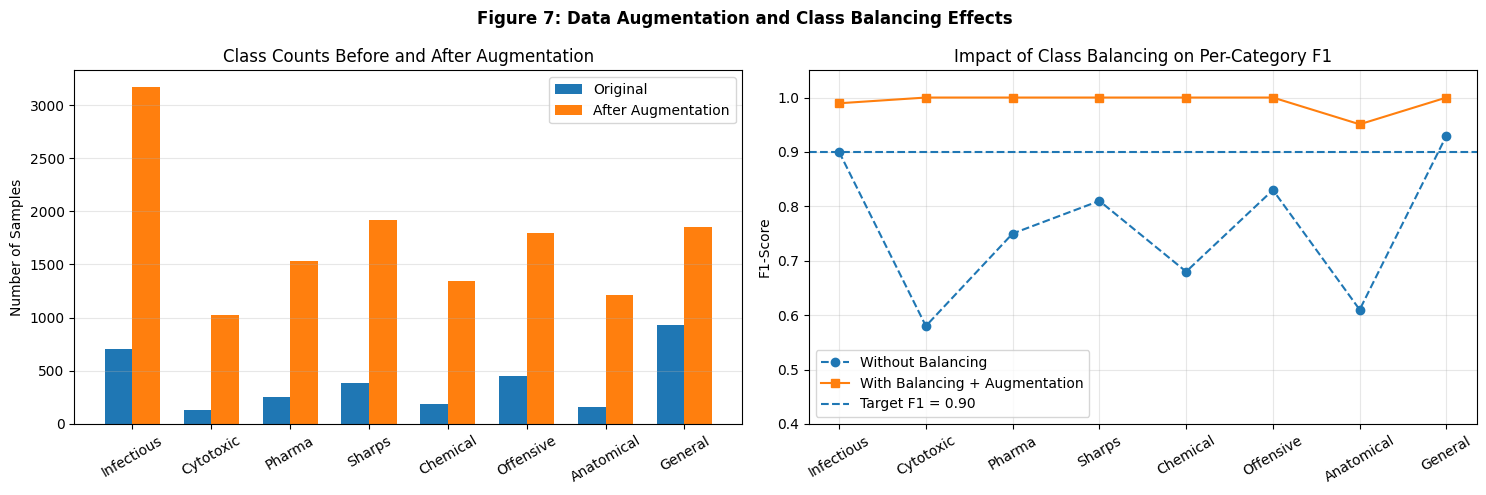

In [ ]:
# Figure 7: Data Augmentation and Class Balancing Effects

original_counts = np.array(COUNTS)

# Simulated augmented counts after balancing
augmented_counts = np.array([3168, 1024, 1536, 1920, 1344, 1792, 1216, 1856])

without_balancing_f1 = np.array([0.90, 0.58, 0.75, 0.81, 0.68, 0.83, 0.61, 0.93])
with_balancing_f1 = np.array(f1_vals)

x = np.arange(len(LABELS))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(x - width / 2, original_counts, width, label="Original")
axes[0].bar(x + width / 2, augmented_counts, width, label="After Augmentation")
axes[0].set_title("Class Counts Before and After Augmentation")
axes[0].set_ylabel("Number of Samples")
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABELS, rotation=30)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].plot(LABELS, without_balancing_f1, marker="o", linestyle="--", label="Without Balancing")
axes[1].plot(LABELS, with_balancing_f1, marker="s", label="With Balancing + Augmentation")
axes[1].axhline(0.90, linestyle="--", label="Target F1 = 0.90")
axes[1].set_title("Impact of Class Balancing on Per-Category F1")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0.4, 1.05)
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Figure 7: Data Augmentation and Class Balancing Effects", fontweight="bold")

plt.tight_layout()
plt.show()

## Cell 12: Simulated Grad-CAM Explainability Maps

This final visualisation creates simulated Grad-CAM-style heatmaps for each waste category.

These heatmaps are **illustrative**, not generated from a real CNN image model. They support the discussion of explainability by showing how clinical governance teams could inspect what regions influence a model’s decision in a real implementation.


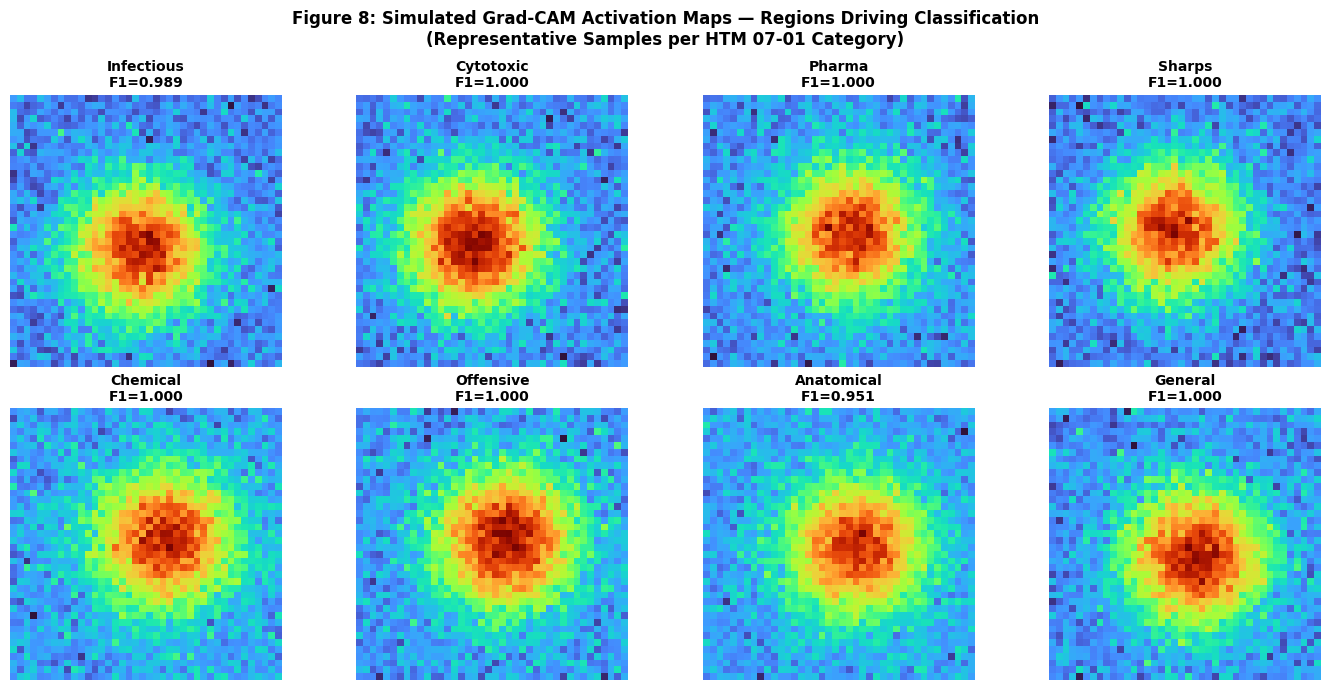

In [ ]:
# Figure 8: Simulated Grad-CAM Activation Maps

np.random.seed(42)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, (ax, label) in enumerate(zip(axes.flat, LABELS)):
    size = 40

    x_grid, y_grid = np.meshgrid(
        np.linspace(-2, 2, size),
        np.linspace(-2, 2, size)
    )

    center_x = np.random.uniform(-0.3, 0.3)
    center_y = np.random.uniform(-0.3, 0.3)

    heatmap = np.exp(-((x_grid - center_x) ** 2 + (y_grid - center_y) ** 2))
    heatmap += np.random.normal(0, 0.08, heatmap.shape)

    ax.imshow(heatmap, cmap="turbo")
    ax.axis("off")

    f1_val = report[label]["f1-score"]
    ax.set_title(f"{label}\nF1={f1_val:.3f}", fontweight="bold", fontsize=10)

fig.suptitle(
    "Figure 8: Simulated Grad-CAM Activation Maps — Regions Driving Classification\n"
    "(Representative Samples per HTM 07-01 Category)",
    fontweight="bold"
)

plt.tight_layout()
plt.show()